In [1]:
import proplot as pplt
import numpy as np
import xarray as xr
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import glob
import dask.array as da
from metpy.units import units
from scipy import stats
from scipy.stats import linregress

In [2]:
data_hist_ssp245_MPI_ESM  = '/work/mh0033/m301036/LSAT/CMIP6-MPI-M-LR/MergeDataOut/psl_Amon_1850-2022_*.nc'

ds = xr.open_mfdataset(data_hist_ssp245_MPI_ESM, combine = 'nested', concat_dim = 'run')
ds

<xarray.Dataset>
Dimensions:    (time: 2076, run: 30, bnds: 2, lon: 180, lat: 90)
Coordinates:
  * time       (time) datetime64[ns] 1850-01-16T12:00:00 ... 2022-12-16T12:00:00
  * lon        (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * lat        (lat) float64 -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
Dimensions without coordinates: run, bnds
Data variables:
    time_bnds  (run, time, bnds) datetime64[ns] dask.array<chunksize=(1, 2076, 2), meta=np.ndarray>
    psl        (run, time, lat, lon) float32 dask.array<chunksize=(1, 2076, 90, 180), meta=np.ndarray>
Attributes: (12/49)
    CDI:                    Climate Data Interface version 2.0.3 (https://mpi...
    source:                 MPI-ESM1.2-LR (2017): \naerosol: none, prescribed...
    institution:            Max Planck Institute for Meteorology, Hamburg 201...
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    ...                     ...
    variable_id:            psl
    variant_label:          r1i1p1f1
    license:                CMIP6 model data produced by MPI-M is licensed un...
    cmor_version:           3.5.0
    tracking_id:            hdl:21.14100/2d4e90e1-d70a-49f4-8374-eb769a0b143d
    CDO:                    Climate Data Operators version 2.0.3 (https://mpi...

In [3]:
slp = ds['psl'].loc[:,'1850-01-01':'2014-12-31',:,:]
slp = slp/100.0
slp_climatology = slp.groupby('time.month').mean(dim='time')
slp_ano = slp.groupby('time.month') - slp_climatology
slp_ano
lat = slp_ano['lat']
lon = slp_ano['lon']

/home/m/m301036/.conda/envs/mykernel/lib/python3.9/site-packages/xarray/core/indexing.py:1440: PerformanceWarning: Slicing with an out-of-order index is generating 165 times more chunks
  return self.array[key]


In [4]:
#Separate data into monthly and output as new nc file
time_data = slp_ano['time']
time_index = pd.to_datetime(time_data.values)
time_index

DatetimeIndex(['1850-01-16 12:00:00', '1850-02-15 00:00:00',
               '1850-03-16 12:00:00', '1850-04-16 00:00:00',
               '1850-05-16 12:00:00', '1850-06-16 00:00:00',
               '1850-07-16 12:00:00', '1850-08-16 12:00:00',
               '1850-09-16 00:00:00', '1850-10-16 12:00:00',
               ...
               '2014-03-16 12:00:00', '2014-04-16 00:00:00',
               '2014-05-16 12:00:00', '2014-06-16 00:00:00',
               '2014-07-16 12:00:00', '2014-08-16 12:00:00',
               '2014-09-16 00:00:00', '2014-10-16 12:00:00',
               '2014-11-16 00:00:00', '2014-12-16 12:00:00'],
              dtype='datetime64[ns]', length=1980, freq=None)

In [5]:
weights = np.cos(np.deg2rad(slp.lat))*xr.ones_like(slp['lon'])

In [6]:
slp_ano_weighted = slp_ano.weighted(weights)
# display(slp_ano_weighted)
slp_ano_weighted_mean = slp_ano_weighted.mean(dim=['lat','lon'])
slp_ano_weighted_mean

<xarray.DataArray 'psl' (run: 30, time: 1980)>
dask.array<truediv, shape=(30, 1980), dtype=float64, chunksize=(1, 1), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 1850-01-16T12:00:00 ... 2014-12-16T12:00:00
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: run

In [7]:
slp_ano_annual = slp_ano_weighted_mean.groupby('time.year').mean('time')
slp_ano_annual
# display(slp_ano_annual.min().values)
# tas_ano_annual.max().values

<xarray.DataArray 'psl' (run: 30, year: 165)>
dask.array<transpose, shape=(30, 165), dtype=float64, chunksize=(1, 1), chunktype=numpy.ndarray>
Coordinates:
  * year     (year) int64 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013 2014
Dimensions without coordinates: run

In [8]:
seasons = ['JJA', 'DJF', 'MAM', 'SON']
season_means = {}

for season in seasons:
    if season == 'JJA':
        months = [6,7,8]
    elif season == 'DJF':
        months =[12,1,2]
    elif season == 'MAM':
        months = [3,4,5]
    elif season == 'SON':
        months = [9,10,11]
    
    season_months = slp_ano.sel(time=slp.time.dt.month.isin(months),lat=slice(0,90))
    
    # Calculate the seasonal mean SAT anomalies
    season_mean_anomalies = (season_months * weights).mean(dim=['lat', 'lon']) / weights.mean(dim=['lat', 'lon'])
    
    # Store the seasonal mean in the dictionary
    season_means[season] = season_mean_anomalies

# Access the multiyear JJA mean SAT anomalies
    
JJA_slp = season_means['JJA']
DJF_slp = season_means['DJF']
MAM_slp = season_means['MAM']
SON_slp = season_means['SON']


JJA_slp,DJF_slp,MAM_slp,SON_slp

(<xarray.DataArray (run: 30, time: 495)>
 dask.array<truediv, shape=(30, 495), dtype=float64, chunksize=(1, 1), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) datetime64[ns] 1850-06-16 ... 2014-08-16T12:00:00
     month    (time) int64 6 7 8 6 7 8 6 7 8 6 7 8 6 ... 6 7 8 6 7 8 6 7 8 6 7 8
 Dimensions without coordinates: run,
 <xarray.DataArray (run: 30, time: 495)>
 dask.array<truediv, shape=(30, 495), dtype=float64, chunksize=(1, 1), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) datetime64[ns] 1850-01-16T12:00:00 ... 2014-12-16T12:00:00
     month    (time) int64 1 2 12 1 2 12 1 2 12 1 2 ... 2 12 1 2 12 1 2 12 1 2 12
 Dimensions without coordinates: run,
 <xarray.DataArray (run: 30, time: 495)>
 dask.array<truediv, shape=(30, 495), dtype=float64, chunksize=(1, 1), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) datetime64[ns] 1850-03-16T12:00:00 ... 2014-05-16T12:00:00
     month    (time) int64 3 4 5 3 4 5 3 4 5 3 4 5 3 ... 3 4 5 3 4 5 3 4 5 3 

In [9]:
DJF_slp_mean = DJF_slp.groupby('time.year').mean(dim='time')
JJA_slp_mean = JJA_slp.groupby('time.year').mean(dim='time')
MAM_slp_mean = MAM_slp.groupby('time.year').mean(dim='time')
SON_slp_mean = SON_slp.groupby('time.year').mean(dim='time')

# JJA_slp_mean[0,:].values
DJF_slp_mean,JJA_slp_mean

(<xarray.DataArray (run: 30, year: 165)>
 dask.array<transpose, shape=(30, 165), dtype=float64, chunksize=(1, 1), chunktype=numpy.ndarray>
 Coordinates:
   * year     (year) int64 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013 2014
 Dimensions without coordinates: run,
 <xarray.DataArray (run: 30, year: 165)>
 dask.array<transpose, shape=(30, 165), dtype=float64, chunksize=(1, 1), chunktype=numpy.ndarray>
 Coordinates:
   * year     (year) int64 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013 2014
 Dimensions without coordinates: run)

In [10]:
window_size =65
rolled = slp_ano_annual.rolling(year=65, center=True).construct("window_size")
rolled[0,:,:]

<xarray.DataArray 'psl' (year: 165, window_size: 65)>
dask.array<getitem, shape=(165, 65), dtype=float64, chunksize=(65, 65), chunktype=numpy.ndarray>
Coordinates:
  * year     (year) int64 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013 2014
Dimensions without coordinates: window_size

In [11]:
#mask 
nyears = 165
windows = 101
k=0
mask = np.zeros((windows, nyears))
for i in range(windows):
    mask[i,k:k+65]=1
    k=k+1

In [12]:
mask[0],mask[1]

windows = xr.DataArray(np.arange(0,101,1), dims='windows')
year = xr.DataArray(np.arange(1850, 2015,1), dims='year')
new_dims = {'windows': windows, 'year': year}
mask = xr.DataArray(mask,dims=('windows','year'), coords=new_dims)
type(mask)
display(mask)

<xarray.DataArray (windows: 101, year: 165)>
array([[1., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 1., 0.],
       [0., 0., 0., ..., 1., 1., 1.]])
Coordinates:
  * windows  (windows) int64 0 1 2 3 4 5 6 7 8 9 ... 92 93 94 95 96 97 98 99 100
  * year     (year) int64 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013 2014

In [13]:
slp_ano_annual= xr.DataArray(slp_ano_annual)
display(slp_ano_annual)
# slp_ano_annual_reshaped = slp_ano_annual.broadcast_like(mask)
masked_annual_slp = mask*slp_ano_annual
masked_annual_slp

<xarray.DataArray 'psl' (run: 30, year: 165)>
dask.array<transpose, shape=(30, 165), dtype=float64, chunksize=(1, 1), chunktype=numpy.ndarray>
Coordinates:
  * year     (year) int64 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013 2014
Dimensions without coordinates: run

<xarray.DataArray (windows: 101, year: 165, run: 30)>
dask.array<multiply, shape=(101, 165, 30), dtype=float64, chunksize=(101, 1, 1), chunktype=numpy.ndarray>
Coordinates:
  * windows  (windows) int64 0 1 2 3 4 5 6 7 8 9 ... 92 93 94 95 96 97 98 99 100
  * year     (year) int64 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013 2014
Dimensions without coordinates: run

In [14]:
#the data should be the masked_annual_tas
#  dim is the selected run
#  trend is the returning running 15 year trend with the dimension size '101'
def polyfit_run(data):
    trend = np.zeros(101)
    for i in range(101):
        trend[i] = np.polyfit(range(65), data[i,:][data[i,:] != 0], deg=1)[0]
    return trend

In [15]:
window_size = 65

num_runs= 30
num_points  = 165
num_windows = num_points - window_size + 1 

trend = np.zeros((num_runs,num_windows))

for irun in range(30):
    trend[irun,:]=polyfit_run(masked_annual_slp.isel(run=irun).values)
  

In [16]:
slp_ano_JJA= xr.DataArray(JJA_slp_mean)
display(slp_ano_JJA)
# slp_ano_annual_reshaped = slp_ano_annual.broadcast_like(mask)
masked_JJA_slp = mask*slp_ano_JJA
masked_JJA_slp

<xarray.DataArray (run: 30, year: 165)>
dask.array<transpose, shape=(30, 165), dtype=float64, chunksize=(1, 1), chunktype=numpy.ndarray>
Coordinates:
  * year     (year) int64 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013 2014
Dimensions without coordinates: run

<xarray.DataArray (windows: 101, year: 165, run: 30)>
dask.array<multiply, shape=(101, 165, 30), dtype=float64, chunksize=(101, 1, 1), chunktype=numpy.ndarray>
Coordinates:
  * windows  (windows) int64 0 1 2 3 4 5 6 7 8 9 ... 92 93 94 95 96 97 98 99 100
  * year     (year) int64 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013 2014
Dimensions without coordinates: run

In [17]:
slp_ano_DJF= xr.DataArray(DJF_slp_mean)
display(slp_ano_DJF)
# slp_ano_annual_reshaped = slp_ano_annual.broadcast_like(mask)
masked_DJF_slp = mask*slp_ano_DJF
masked_DJF_slp

<xarray.DataArray (run: 30, year: 165)>
dask.array<transpose, shape=(30, 165), dtype=float64, chunksize=(1, 1), chunktype=numpy.ndarray>
Coordinates:
  * year     (year) int64 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013 2014
Dimensions without coordinates: run

<xarray.DataArray (windows: 101, year: 165, run: 30)>
dask.array<multiply, shape=(101, 165, 30), dtype=float64, chunksize=(101, 1, 1), chunktype=numpy.ndarray>
Coordinates:
  * windows  (windows) int64 0 1 2 3 4 5 6 7 8 9 ... 92 93 94 95 96 97 98 99 100
  * year     (year) int64 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013 2014
Dimensions without coordinates: run

In [18]:
slp_ano_MAM= xr.DataArray(MAM_slp_mean)
display(slp_ano_MAM)
# slp_ano_annual_reshaped = slp_ano_annual.broadcast_like(mask)
masked_MAM_slp = mask*slp_ano_MAM
masked_MAM_slp

<xarray.DataArray (run: 30, year: 165)>
dask.array<transpose, shape=(30, 165), dtype=float64, chunksize=(1, 1), chunktype=numpy.ndarray>
Coordinates:
  * year     (year) int64 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013 2014
Dimensions without coordinates: run

<xarray.DataArray (windows: 101, year: 165, run: 30)>
dask.array<multiply, shape=(101, 165, 30), dtype=float64, chunksize=(101, 1, 1), chunktype=numpy.ndarray>
Coordinates:
  * windows  (windows) int64 0 1 2 3 4 5 6 7 8 9 ... 92 93 94 95 96 97 98 99 100
  * year     (year) int64 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013 2014
Dimensions without coordinates: run

In [19]:
slp_ano_SON= xr.DataArray(SON_slp_mean)
display(slp_ano_SON)
# slp_ano_annual_reshaped = slp_ano_annual.broadcast_like(mask)
masked_SON_slp = mask*slp_ano_SON
masked_SON_slp

<xarray.DataArray (run: 30, year: 165)>
dask.array<transpose, shape=(30, 165), dtype=float64, chunksize=(1, 1), chunktype=numpy.ndarray>
Coordinates:
  * year     (year) int64 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013 2014
Dimensions without coordinates: run

<xarray.DataArray (windows: 101, year: 165, run: 30)>
dask.array<multiply, shape=(101, 165, 30), dtype=float64, chunksize=(101, 1, 1), chunktype=numpy.ndarray>
Coordinates:
  * windows  (windows) int64 0 1 2 3 4 5 6 7 8 9 ... 92 93 94 95 96 97 98 99 100
  * year     (year) int64 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013 2014
Dimensions without coordinates: run

In [20]:
trend_JJA = np.zeros((num_runs,num_windows))

for irun in range(30):
    trend_JJA[irun,:]=polyfit_run(masked_JJA_slp.isel(run=irun).values)

In [21]:
trend_DJF = np.zeros((num_runs,num_windows))

for irun in range(30):
    trend_DJF[irun,:]=polyfit_run(masked_DJF_slp.isel(run=irun).values)

In [22]:
trend_SON = np.zeros((num_runs,num_windows))

for irun in range(30):
    trend_SON[irun,:]=polyfit_run(masked_SON_slp.isel(run=irun).values)

In [23]:
trend_MAM = np.zeros((num_runs,num_windows))

for irun in range(30):
    trend_MAM[irun,:]=polyfit_run(masked_MAM_slp.isel(run=irun).values)

In [24]:
print(np.shape(trend_DJF))

(30, 101)


In [25]:
#Calculate the 15yr running trend time series
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import signal
from sklearn.linear_model import LinearRegression

In [26]:
#output 30 run annual mean SAT
# tas_ano_annual_np = tas_ano_annual['tas'].values
x = np.arange(1850,1951,1)
num_time_series = slp_ano_annual.shape[0]

#calculate the ensemble mean of the MPI-ESM-LR 
slp_annual_mean = slp_ano_annual.mean('run')
# tas_annual_mean.values

In [27]:
# print(min(tas_annual_mean))
# print(max(tas_annual_mean))

In [28]:
year = xr.DataArray(np.arange(1850,1951,1),dims='year')
print(len(year))
trend_mean = trend.mean((0))
trend_JJA_mean = trend_JJA.mean((0))
trend_DJF_mean = trend_DJF.mean((0))
trend_MAM_mean = trend_MAM.mean((0))
trend_SON_mean = trend_SON.mean((0))

trend_DJF_mean.shape
trend_mean = xr.DataArray(trend_mean,dims=('year'), coords={'year': year})
trend_JJA_mean = xr.DataArray(trend_JJA_mean,dims=('year'), coords={'year': year})
trend_DJF_mean = xr.DataArray(trend_DJF_mean,dims=('year'), coords={'year': year})
trend_MAM_mean = xr.DataArray(trend_MAM_mean,dims=('year'), coords={'year': year})
trend_SON_mean = xr.DataArray(trend_SON_mean,dims=('year'), coords={'year': year})

101


In [29]:
#input trend data
NOAA_annual = np.genfromtxt(fname='/work/mh0033/m301036/Land_surf_temp/1850-2100Analyses/Data-output/SLP_annual_NH_65yr_trend.txt',delimiter='\t', skip_header=1)
NOAA_JJA = np.genfromtxt(fname='/work/mh0033/m301036/Land_surf_temp/1850-2100Analyses/Data-output/SLP_JJA_NH_65yr_trend.txt',delimiter='\t', skip_header=1)
NOAA_DJF = np.genfromtxt(fname='/work/mh0033/m301036/Land_surf_temp/1850-2100Analyses/Data-output/SLP_DJF_NH_65yr_trend.txt',delimiter='\t', skip_header=1)
NOAA_MAM = np.genfromtxt(fname='/work/mh0033/m301036/Land_surf_temp/1850-2100Analyses/Data-output/SLP_MAM_NH_65yr_trend.txt',delimiter='\t', skip_header=1)
NOAA_SON = np.genfromtxt(fname='/work/mh0033/m301036/Land_surf_temp/1850-2100Analyses/Data-output/SLP_SON_NH_65yr_trend.txt',delimiter='\t', skip_header=1)

NOAA_trend_annual = NOAA_annual[:,1]
NOAA_trend_JJA = NOAA_JJA[:,1]
NOAA_trend_DJF = NOAA_DJF[:,1]
NOAA_trend_SON = NOAA_SON[:,1]
NOAA_trend_MAM = NOAA_MAM[:,1]

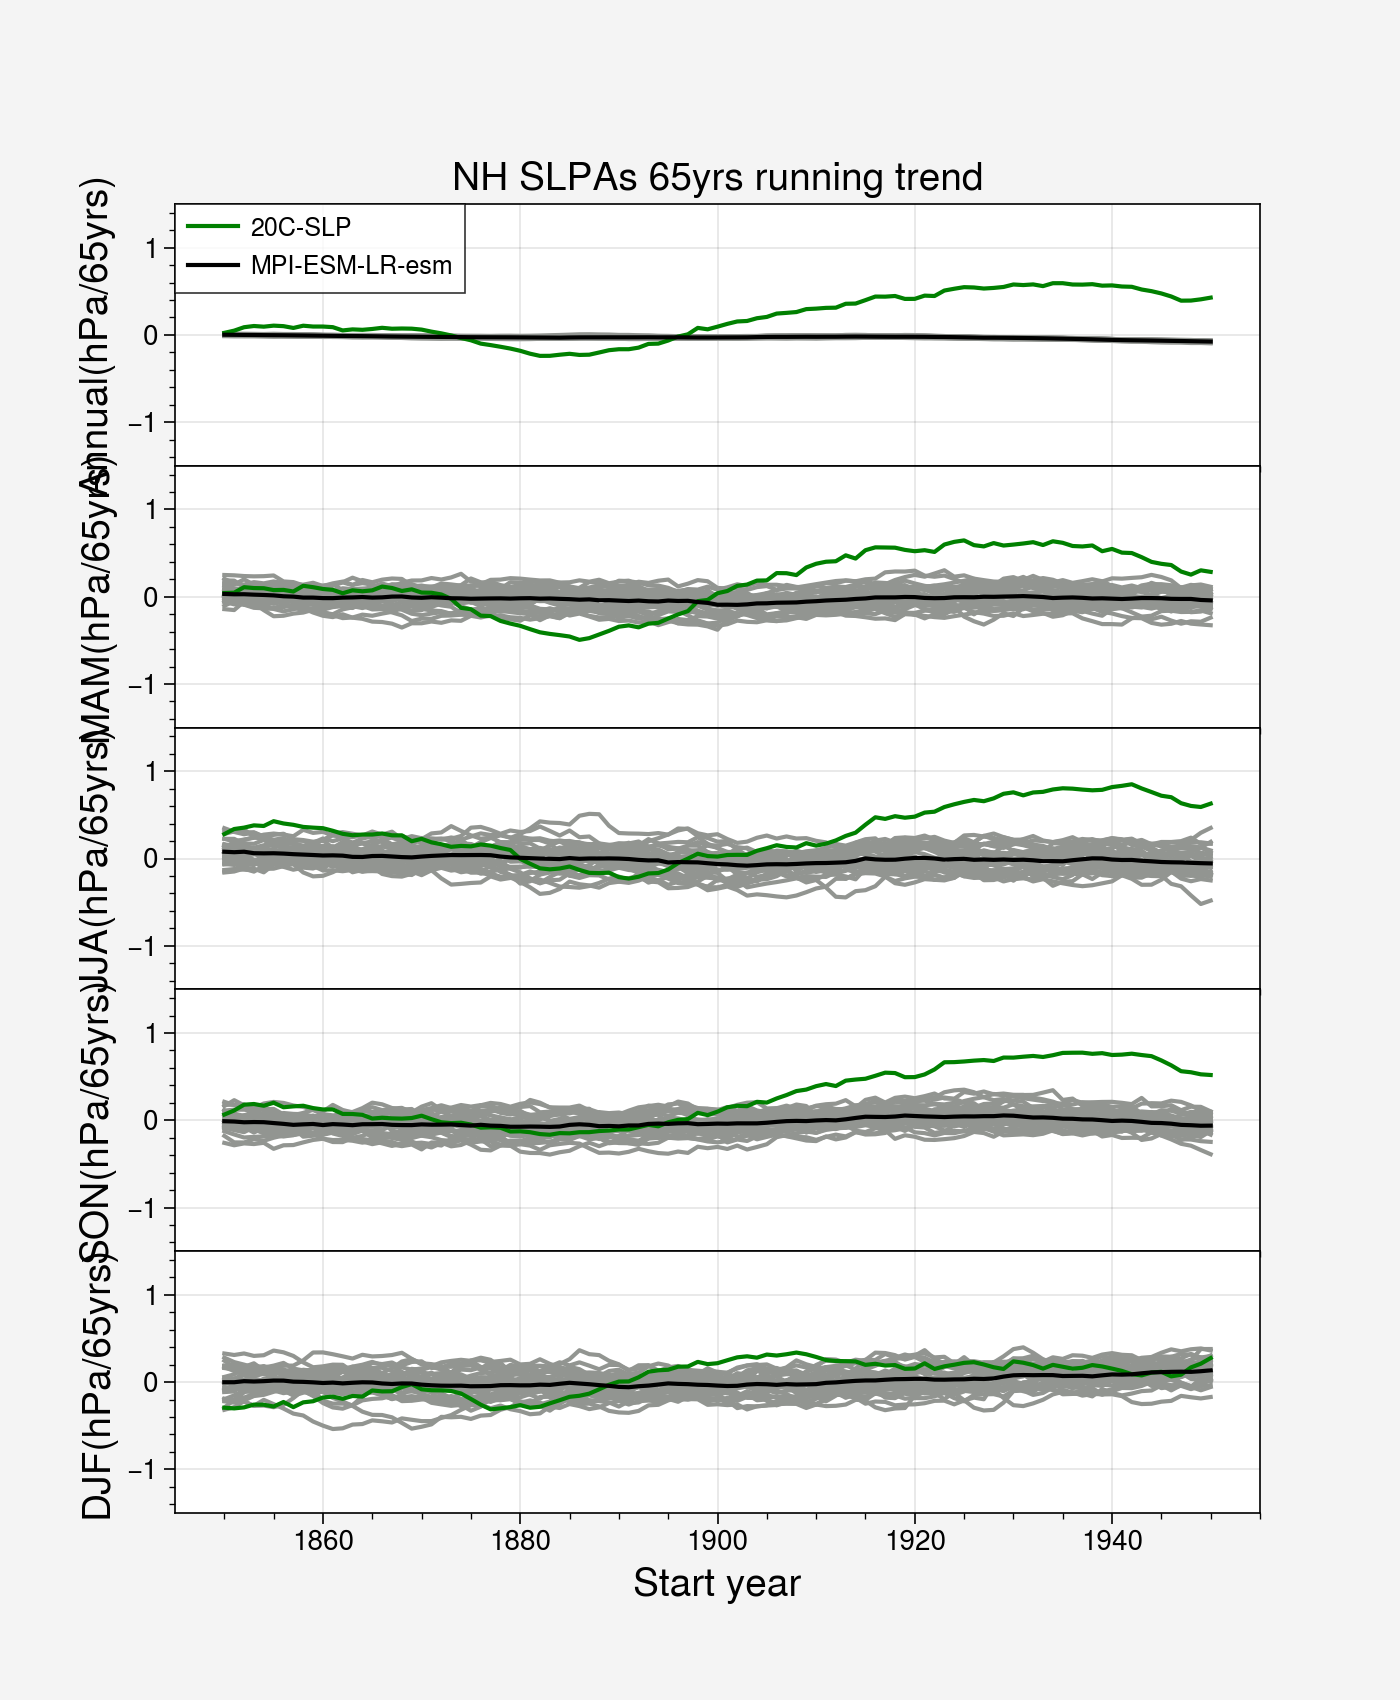

In [30]:
fig,axs = plt.subplots(5,1, figsize=(7,8.5), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0)

for i in range(num_time_series):
    axs[0].plot(x, trend[i, :]*65, color='gray')
    
axs[0].plot(x, NOAA_trend_annual, color='green', label='20C-SLP')

axs[0].plot(x, trend_mean*65, color='black', label='MPI-ESM-LR-esm')
axs[0].set(ylim=(-1.5,1.5))
axs[0].set_title('NH SLPAs 65yrs running trend',fontsize=14)
axs[0].set_ylabel('Annual(hPa/65yrs)', fontsize=14)
axs[0].set_xlabel('Start year', fontsize=14)
# axs[0].grid(visible=False, which='major', axis='y')
axs[0].tick_params(axis='x', labelsize=10)
axs[0].tick_params(axis='y', labelsize=10)
axs[0].legend()
# Plot the MAM time series
for i in range(num_time_series):
    axs[1].plot(x, trend_MAM[i, :]*65, color='gray')

axs[1].plot(x, NOAA_trend_MAM, color='green')
axs[1].plot(x, trend_MAM_mean*65, color='black')
axs[1].set_ylabel('MAM(hPa/65yrs)', fontsize=14)
axs[1].set_xlabel('Start year', fontsize=14)
# axs[1].grid(visible=False, which='major', axis='y')
axs[1].tick_params(axis='x', labelsize=10)
axs[1].tick_params(axis='y', labelsize=10)

# Plot the JJA time series
for i in range(num_time_series):
    axs[2].plot(x, trend_JJA[i, :]*65, color='gray')
    
axs[2].plot(x, NOAA_trend_JJA, color='green')
axs[2].plot(x, trend_JJA_mean*65, color='black')
# axs[2].set_title('MPI-ESM1-LR 1850-2014 JJA SAT')
axs[2].set_ylabel('JJA(hPa/65yrs)', fontsize=14)
axs[2].set_xlabel('Start year', fontsize=14)
# axs[2].grid(visible=False, which='major', axis='y')
axs[2].tick_params(axis='x', labelsize=10)
axs[2].tick_params(axis='y', labelsize=10)

# Plot the SON time series
for i in range(num_time_series):
    axs[3].plot(x, trend_SON[i, :]*65, color='gray')
    
axs[3].plot(x, NOAA_trend_SON, color='green')
axs[3].plot(x, trend_SON_mean*65, color='black')
# axs[3].set_title('MPI-ESM1-LR 1850-2014 SON SAT')
axs[3].set_ylabel('SON(hPa/65yrs)', fontsize=14)
axs[3].set_xlabel('Start year', fontsize=14)
# axs[3].grid(visible=False, which='major', axis='y')
axs[3].tick_params(axis='x', labelsize=10)
axs[3].tick_params(axis='y', labelsize=10)

# Plot the DJF time series
for i in range(num_time_series):
    axs[4].plot(x, trend_DJF[i, :]*65, color='gray')
    
axs[4].plot(x, NOAA_trend_DJF, color='green')
axs[4].plot(x, trend_DJF_mean*65, color='black')
# axs[4].set_title('MPI-ESM1-LR 1850-2014 DJF SAT')
axs[4].set_ylabel('DJF(hPa/65yrs)', fontsize=14)
axs[4].set_xlabel('Start year', fontsize=14)
# axs[4].grid(visible=False, which='major', axis='y')
axs[4].tick_params(axis='x', labelsize=10)
axs[4].tick_params(axis='y', labelsize=10)

plt.show()

In [31]:
# fig.savefig("./MPI-ESM-LR-NH_SLPAs_65yr_running_trend.png")

## Extraction the 1958-2022 trend values

In [32]:
# ERA5_DJF_trend = ERA5_trend_DJF[-1]*65.0
# ERA5_DJF_trend = np.round(ERA5_DJF_trend, decimals=2)
# print(ERA5_DJF_trend)

# ERA5_JJA_trend = ERA5_trend_JJA[-1]*65.0
# ERA5_JJA_trend = np.round(ERA5_JJA_trend, decimals=2)
# print(ERA5_JJA_trend)

# ERA5_SON_trend = ERA5_trend_SON[-1]*65.0
# ERA5_SON_trend = np.round(ERA5_SON_trend, decimals=2)
# print(ERA5_SON_trend)

# ERA5_MAM_trend = ERA5_trend_MAM[-1]*65.0
# ERA5_MAM_trend = np.round(ERA5_MAM_trend, decimals=2)
# print(ERA5_MAM_trend)

In [ ]:
trend_30runs_DJF = pd.DataFrame({'run': np.arange(1,31,1), 'values': trend_DJF[:,-1]*65.0})
trend_30runs_DJF.to_csv('MPI-ESM-LR_NH_SLP_65yr_DJF_trend.txt', sep='\t', index=False)

In [ ]:
trend_30runs_JJA = pd.DataFrame({'run': np.arange(1,31,1), 'values': trend_JJA[:,-1]*65.0})
trend_30runs_JJA.to_csv('MPI-ESM-LR_NH_SLP_65yr_JJA_trend.txt', sep='\t', index=False)

trend_30runs_SON = pd.DataFrame({'run': np.arange(1,31,1), 'values': trend_SON[:,-1]*65.0})
trend_30runs_SON.to_csv('MPI-ESM-LR_NH_SLP_65yr_SON_trend.txt', sep='\t', index=False)

trend_30runs_MAM = pd.DataFrame({'run': np.arange(1,31,1), 'values': trend_MAM[:,-1]*65.0})
trend_30runs_MAM.to_csv('MPI-ESM-LR_NH_SLP_65yr_MAM_trend.txt', sep='\t', index=False)

## 1893-1957 trend values

In [72]:
NOAA_DJF_trend = NOAA_trend_DJF[43]
NOAA_DJF_trend = np.round(NOAA_DJF_trend, decimals=2)
print(NOAA_DJF_trend)

NOAA_JJA_trend = NOAA_trend_JJA[43]
NOAA_JJA_trend = np.round(NOAA_JJA_trend, decimals=2)
print(NOAA_JJA_trend)

NOAA_SON_trend = NOAA_trend_SON[43]
NOAA_SON_trend = np.round(NOAA_SON_trend, decimals=2)
print(NOAA_SON_trend)

NOAA_MAM_trend = NOAA_trend_MAM[43]
NOAA_MAM_trend = np.round(NOAA_MAM_trend, decimals=2)
print(NOAA_MAM_trend)

0.12
-0.17
-0.05
-0.31


In [73]:
trend_1893_DJF = pd.DataFrame({'run': np.arange(1,31,1), 'values': trend_DJF[:,43]*65.0})
trend_1893_DJF.to_csv('MPI-ESM-LR_NH_SLP_1893_65yr_DJF_trend.txt', sep='\t', index=False)

trend_1893_JJA = pd.DataFrame({'run': np.arange(1,31,1), 'values': trend_JJA[:,43]*65.0})
trend_1893_JJA.to_csv('MPI-ESM-LR_NH_SLP_1893_65yr_JJA_trend.txt', sep='\t', index=False)

trend_1893_SON = pd.DataFrame({'run': np.arange(1,31,1), 'values': trend_SON[:,43]*65.0})
trend_1893_SON.to_csv('MPI-ESM-LR_NH_SLP_1893_65yr_SON_trend.txt', sep='\t', index=False)

trend_1893_MAM = pd.DataFrame({'run': np.arange(1,31,1), 'values': trend_MAM[:,43]*65.0})
trend_1893_MAM.to_csv('MPI-ESM-LR_NH_SLP_1893_65yr_MAM_trend.txt', sep='\t', index=False)